In [31]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

First 5 X values: [0.75 1.9  1.46 1.2  0.31]
First 5 y values: [6.33 9.41 8.48 5.6  4.72]


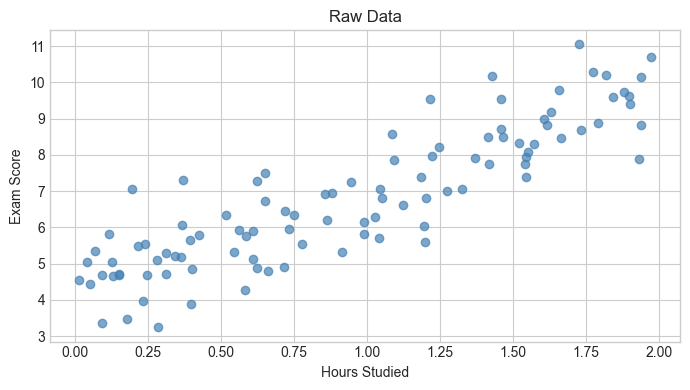

In [32]:
np.random.seed(42)
 
X = 2 * np.random.rand(100)          # hours studied (0 to 2)
y = 4 + 3 * X + np.random.randn(100) # true relationship: y = 4 + 3x + noise
 
print("First 5 X values:", X[:5].round(2))
print("First 5 y values:", y[:5].round(2))
 
plt.figure(figsize=(7, 4))
plt.scatter(X, y, color='steelblue', alpha=0.7)
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("Raw Data")
plt.tight_layout()
plt.show()

In [33]:
split = int(0.8 * len(X))   # 80 samples for train
 
X_train = X[:split] # shape (80,)
X_test  = X[split:] # shape (20,)
y_train = y[:split]
y_test  = y[split:]
 
print(f"\nTrain size: {len(X_train)}, Test size: {len(X_test)}")


Train size: 80, Test size: 20


In [34]:
# Our model:  y_pred = w * x + b
# w = weight (slope), b = bias (intercept)
# We start with random/zero values and let gradient descent fix them.
 
w = 0.0   # slope
b = 0.0   # intercept
 
print(f"\nInitial w = {w}, b = {b}")


Initial w = 0.0, b = 0.0


In [35]:
# We use Mean Squared Error (MSE):
#
#   MSE = (1/N) * Σ (y_pred - y_true)²
#
# The smaller the MSE, the better our line fits the data.
 
def compute_loss(X, y, w, b):
    N = len(X)
    y_pred = w * X + b
    loss = (1 / N) * np.sum((y_pred - y) ** 2)
    return loss
 
initial_loss = compute_loss(X_train, y_train, w, b)
print(f"\nInitial MSE loss: {initial_loss:.4f}")


Initial MSE loss: 48.7927


In [36]:
# We need to know in which direction to nudge w and b to reduce loss.
# That direction comes from calculus — partial derivatives:
#
#   dL/dw = (2/N) * Σ (y_pred - y_true) * x
#   dL/db = (2/N) * Σ (y_pred - y_true)
#
# If gradient is positive → w is too high → decrease w (and vice versa)
 
def compute_gradients(X, y, w, b):
    N = len(X)
    y_pred = w * X + b
    error  = y_pred - y           # residuals
 
    dw = (2 / N) * np.sum(error * X)
    db = (2 / N) * np.sum(error)
    return dw, db
 
dw, db = compute_gradients(X_train, y_train, w, b)
print(f"\nInitial gradients → dw: {dw:.4f}, db: {db:.4f}")


Initial gradients → dw: -14.5327, db: -13.4701


In [37]:
# We update w and b in tiny steps, opposite to the gradient:
#
#   w = w - lr * dw
#   b = b - lr * db
#
# lr (learning rate) controls how big each step is.
 
lr      = 0.1    # learning rate
epochs  = 100    # number of passes over training data
 
loss_history = []
 
for epoch in range(epochs):
 
    # Forward pass: compute current loss
    loss = compute_loss(X_train, y_train, w, b)
    loss_history.append(loss)
 
    # Compute gradients
    dw, db = compute_gradients(X_train, y_train, w, b)
 
    # Update parameters
    w = w - lr * dw
    b = b - lr * db
 
    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | Loss: {loss:.4f} | w: {w:.4f} | b: {b:.4f}")
 
print(f"\nFinal learned parameters → w: {w:.4f}, b: {b:.4f}")

Epoch   0 | Loss: 48.7927 | w: 1.4533 | b: 1.3470
Epoch  10 | Loss: 0.9437 | w: 3.2941 | b: 3.5201
Epoch  20 | Loss: 0.8543 | w: 3.1147 | b: 3.7450
Epoch  30 | Loss: 0.8118 | w: 2.9830 | b: 3.8947
Epoch  40 | Loss: 0.7914 | w: 2.8915 | b: 3.9986
Epoch  50 | Loss: 0.7815 | w: 2.8280 | b: 4.0707
Epoch  60 | Loss: 0.7768 | w: 2.7839 | b: 4.1207
Epoch  70 | Loss: 0.7745 | w: 2.7534 | b: 4.1554
Epoch  80 | Loss: 0.7734 | w: 2.7322 | b: 4.1795
Epoch  90 | Loss: 0.7729 | w: 2.7174 | b: 4.1962

Final learned parameters → w: 2.7081, b: 4.2068


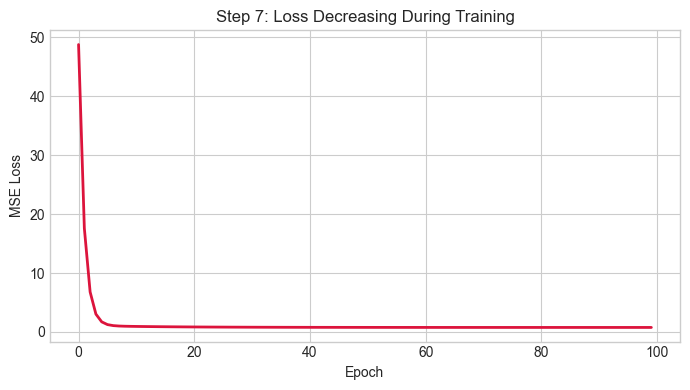

In [38]:
plt.figure(figsize=(7, 4))
plt.plot(loss_history, color='crimson', linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Step 7: Loss Decreasing During Training")
plt.tight_layout()
plt.show()
 

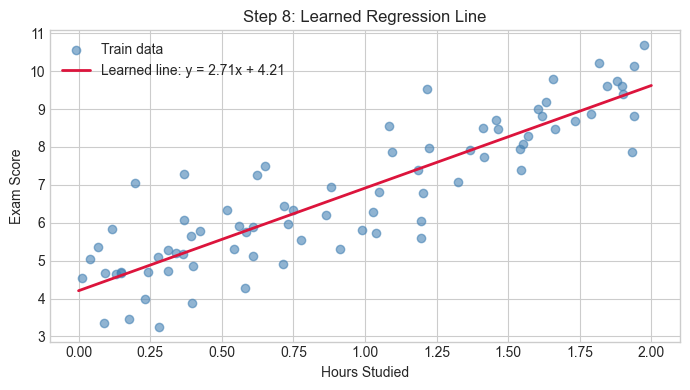

In [39]:
# VISUALIZE THE LEARNED LINE ON TRAINING DATA
 
x_line = np.linspace(0, 2, 100)
y_line = w * x_line + b
 
plt.figure(figsize=(7, 4))
plt.scatter(X_train, y_train, color='steelblue', alpha=0.6, label='Train data')
plt.plot(x_line, y_line, color='crimson', linewidth=2, label=f'Learned line: y = {w:.2f}x + {b:.2f}')
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("Step 8: Learned Regression Line")
plt.legend()
plt.tight_layout()
plt.show()
 


Test MSE: 0.9714


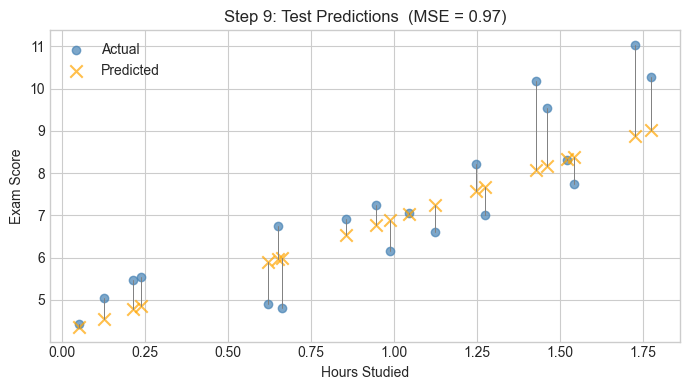

In [40]:
# EVALUATE ON TEST DATA
 
test_loss = compute_loss(X_test, y_test, w, b)
print(f"\nTest MSE: {test_loss:.4f}")
 
y_test_pred = w * X_test + b
 
plt.figure(figsize=(7, 4))
plt.scatter(X_test, y_test, color='steelblue', alpha=0.7, label='Actual')
plt.scatter(X_test, y_test_pred, color='orange', alpha=0.7, marker='x', s=80, label='Predicted')
for i in range(len(X_test)):
    plt.plot([X_test[i], X_test[i]], [y_test[i], y_test_pred[i]], 'gray', linewidth=0.7)
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title(f"Step 9: Test Predictions  (MSE = {test_loss:.2f})")
plt.legend()
plt.tight_layout()
plt.show()